In [1]:
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt

In [2]:
import sys
!{sys.executable} -m pip install pulp


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
pred = pd.read_csv("data/ci_pred_nov_dec_2024.csv")
pred["time"] = pd.to_datetime(pred["time"])
pred = pred.sort_values("time").reset_index(drop=True)

pred.head(), pred.shape

(                       time  ci_actual     ci_pred
 0 2024-11-01 00:00:00+00:00      122.5  114.634265
 1 2024-11-01 01:00:00+00:00      115.0  123.113429
 2 2024-11-01 02:00:00+00:00      106.5  122.690383
 3 2024-11-01 03:00:00+00:00      105.5  116.772964
 4 2024-11-01 04:00:00+00:00      122.0  120.844563,
 (1462, 3))

In [4]:
ci = pred["ci_pred"].values
T = len(ci)
print("Hours in scheduling horizon:", T)
print("First time:", pred.loc[0,"time"], "Last time:", pred.loc[T-1,"time"])

Hours in scheduling horizon: 1462
First time: 2024-11-01 00:00:00+00:00 Last time: 2024-12-31 21:00:00+00:00


In [5]:
np.random.seed(0)

fixed = np.full(T, 40.0)              # fixed load each hour
flex_arrival = np.random.uniform(0, 30, size=T)  # flexible arriving each hour

# total demand if you ran everything immediately
total_now = fixed + flex_arrival

fixed[:5], flex_arrival[:5], total_now[:5]

(array([40., 40., 40., 40., 40.]),
 array([16.46440512, 21.45568099, 18.08290128, 16.34649549, 12.70964398]),
 array([56.46440512, 61.45568099, 58.08290128, 56.34649549, 52.70964398]))

In [6]:
capacity = 80.0   # must be >= average total demand, or it becomes impossible
print("Capacity:", capacity)

Capacity: 80.0


In [7]:
max_delay = 3

In [8]:
model = pulp.LpProblem("carbon_aware_scheduling", pulp.LpMinimize)

# Decision variables: x[t,s] = flexible work arriving at t scheduled at t+s
x = {}
for t in range(T):
    for s in range(max_delay + 1):
        if t + s < T:
            x[(t,s)] = pulp.LpVariable(f"x_{t}_{s}", lowBound=0)

In [9]:
for t in range(T):
    model += pulp.lpSum(x[(t,s)] for s in range(max_delay+1) if (t,s) in x) == flex_arrival[t]

In [10]:
for k in range(T):
    flex_run_k = pulp.lpSum(
        x[(t,s)]
        for t in range(T)
        for s in range(max_delay+1)
        if (t,s) in x and t + s == k
    )
    model += fixed[k] + flex_run_k <= capacity

In [11]:
objective = []
for k in range(T):
    flex_run_k = pulp.lpSum(
        x[(t,s)]
        for t in range(T)
        for s in range(max_delay+1)
        if (t,s) in x and t + s == k
    )
    total_run_k = fixed[k] + flex_run_k
    objective.append(ci[k] * total_run_k)

model += pulp.lpSum(objective)

In [12]:
status = model.solve(pulp.PULP_CBC_CMD(msg=False))
print("Status:", pulp.LpStatus[status])

Status: Optimal


In [13]:
baseline_run = fixed + flex_arrival
baseline_emissions = np.sum(ci * baseline_run)
scheduled_flex_run = np.zeros(T)

for (t,s), var in x.items():
    k = t + s
    scheduled_flex_run[k] += var.value()

scheduled_run = fixed + scheduled_flex_run
scheduled_emissions = np.sum(ci * scheduled_run)

print("Baseline emissions:", baseline_emissions)
print("Scheduled emissions:", scheduled_emissions)
print("Reduction (%):", 100*(baseline_emissions - scheduled_emissions)/baseline_emissions)

Baseline emissions: 11845488.581281628
Scheduled emissions: 11575436.75218099
Reduction (%): 2.2797863274916113


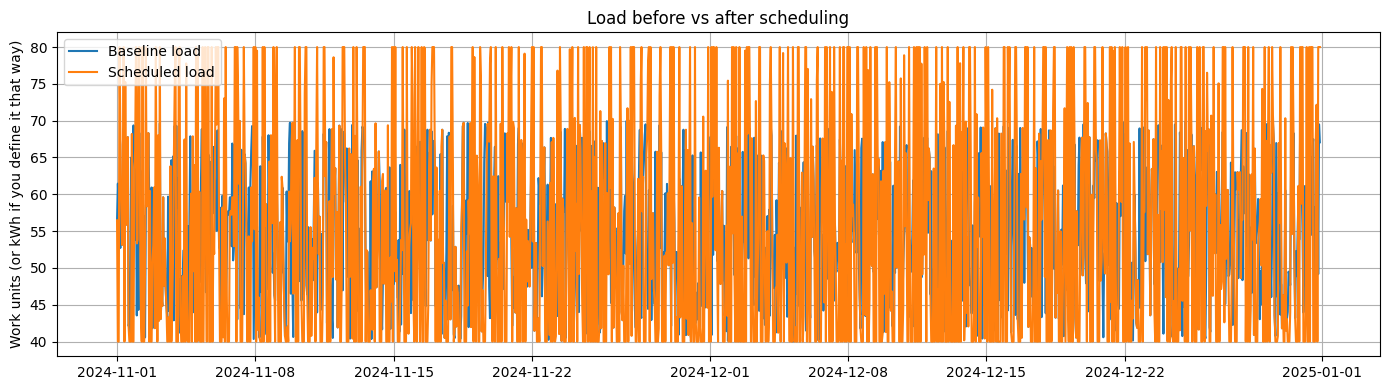

In [14]:
plt.figure(figsize=(14,4))
plt.plot(pred["time"], baseline_run, label="Baseline load")
plt.plot(pred["time"], scheduled_run, label="Scheduled load")
plt.title("Load before vs after scheduling")
plt.ylabel("Work units (or kWh if you define it that way)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

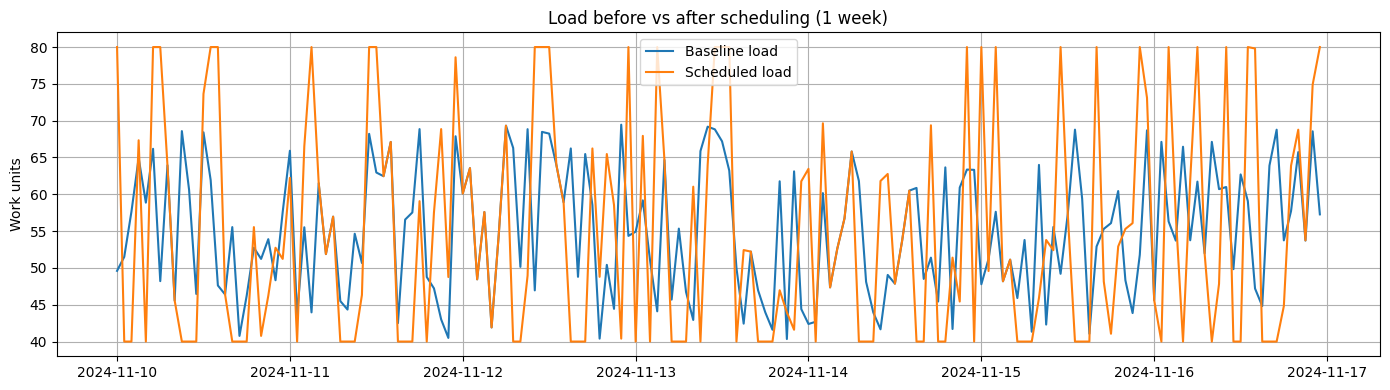

In [15]:
start = "2024-11-10"
end   = "2024-11-17"
mask = (pred["time"] >= start) & (pred["time"] < end)

plt.figure(figsize=(14,4))
plt.plot(pred.loc[mask,"time"], baseline_run[mask], label="Baseline load")
plt.plot(pred.loc[mask,"time"], scheduled_run[mask], label="Scheduled load")
plt.title("Load before vs after scheduling (1 week)")
plt.ylabel("Work units")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
print("Max scheduled load:", scheduled_run.max())
print("Capacity:", capacity)

Max scheduled load: 80.000001
Capacity: 80.0


In [17]:
print("Total baseline work:", baseline_run.sum())
print("Total scheduled work:", scheduled_run.sum())

Total baseline work: 80468.19466561773
Total scheduled work: 80468.19465327181


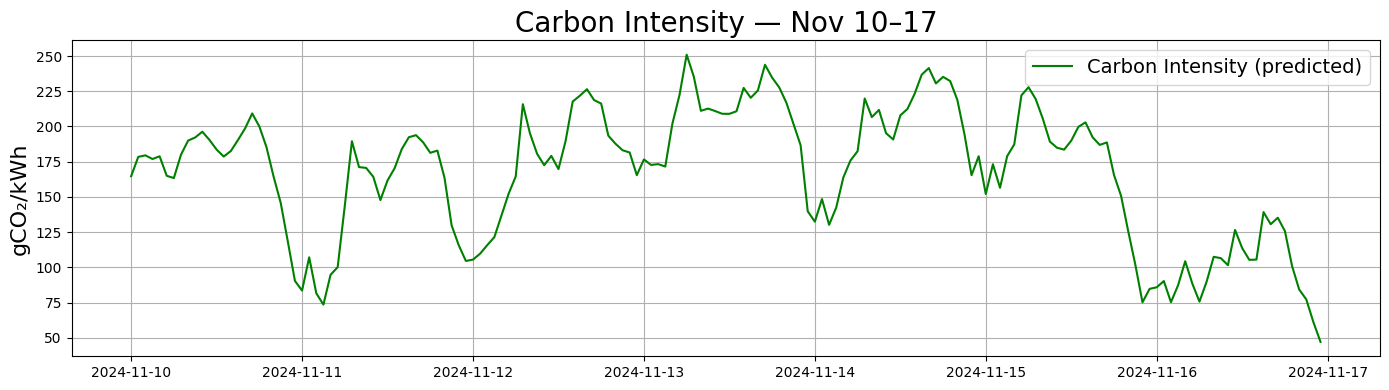

In [18]:
plt.figure(figsize=(14, 4))
plt.plot(pred.loc[mask, "time"], ci[mask], color="green", label="Carbon Intensity (predicted)")
plt.title("Carbon Intensity — Nov 10–17", fontsize=20)
plt.ylabel("gCO₂/kWh", fontsize=16)
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.savefig("fig_carbon_intensity_week.png", dpi=300, bbox_inches="tight")
plt.show()

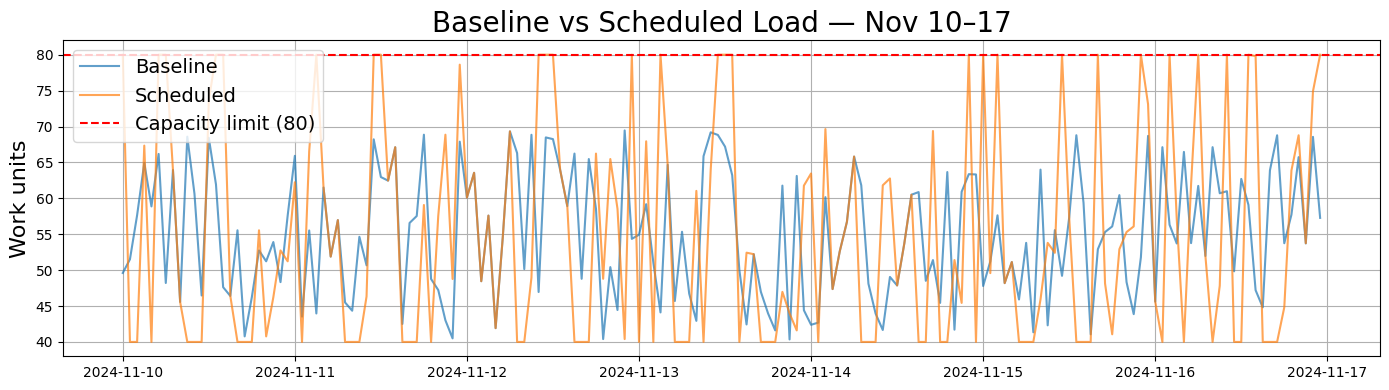

In [19]:
start = "2024-11-10"
end = "2024-11-17"
mask = (pred["time"] >= start) & (pred["time"] < end)

plt.figure(figsize=(14, 4))
plt.plot(pred.loc[mask, "time"], baseline_run[mask], label="Baseline", linewidth=1.5, alpha=0.7)
plt.plot(pred.loc[mask, "time"], scheduled_run[mask], label="Scheduled", linewidth=1.5, alpha=0.7)
plt.axhline(capacity, color="red", linestyle="--", label="Capacity limit (80)")
plt.title("Baseline vs Scheduled Load — Nov 10–17", fontsize=20)
plt.ylabel("Work units", fontsize=16)
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.savefig("fig_scheduler_week.png", dpi=300, bbox_inches="tight")
plt.show()

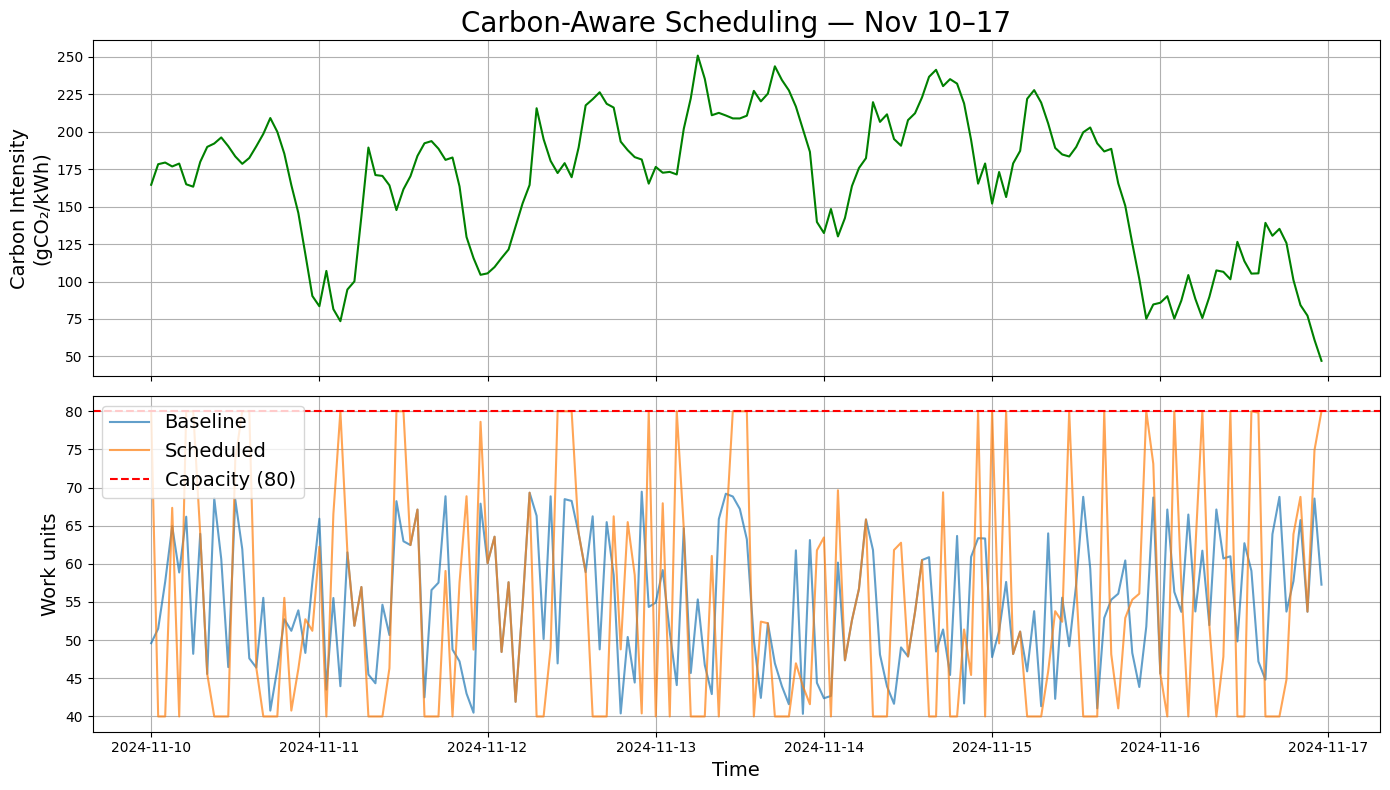

In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(pred.loc[mask, "time"], ci[mask], color="green", linewidth=1.5)
ax1.set_ylabel("Carbon Intensity\n(gCO₂/kWh)", fontsize=14)
ax1.set_title("Carbon-Aware Scheduling — Nov 10–17", fontsize=20)
ax1.grid(True)

ax2.plot(pred.loc[mask, "time"], baseline_run[mask], label="Baseline", linewidth=1.5, alpha=0.7)
ax2.plot(pred.loc[mask, "time"], scheduled_run[mask], label="Scheduled", linewidth=1.5, alpha=0.7)
ax2.axhline(capacity, color="red", linestyle="--", label="Capacity (80)")
ax2.set_ylabel("Work units", fontsize=14)
ax2.set_xlabel("Time", fontsize=14)
ax2.legend(fontsize=14)
ax2.grid(True)

plt.tight_layout()
plt.savefig("fig_scheduler_combined.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# Flexible workload ratios (%) from Table II of the paper (hour 0-23)
# These are the "Proposed" column values
flexible_ratio = np.array([
    40, 31, 33, 23, 27, 27, 18, 24, 24, 28,
    19, 18, 20, 24, 27, 27, 20, 40, 45, 45,
    47, 41, 40, 42
]) / 100  # convert to decimal

# Inflexible workload ratios (%) from Table II
inflexible_ratio = np.array([
    28, 25, 17, 16, 8, 6, 12, 20, 24, 34,
    37, 42, 40, 36, 35, 33, 40, 27, 26, 26,
    25, 29, 30, 21
]) / 100

# Total capacity of data centre in work units
DC_CAPACITY = 100.0  # 100 units = 100% CPU capacity

print("Flexible ratio (midnight to 11pm):", flexible_ratio)
print("Inflexible ratio (midnight to 11pm):", inflexible_ratio)

Flexible ratio (midnight to 11pm): [0.4  0.31 0.33 0.23 0.27 0.27 0.18 0.24 0.24 0.28 0.19 0.18 0.2  0.24
 0.27 0.27 0.2  0.4  0.45 0.45 0.47 0.41 0.4  0.42]
Inflexible ratio (midnight to 11pm): [0.28 0.25 0.17 0.16 0.08 0.06 0.12 0.2  0.24 0.34 0.37 0.42 0.4  0.36
 0.35 0.33 0.4  0.27 0.26 0.26 0.25 0.29 0.3  0.21]


In [22]:
# Get hour of day for each timestamp in the test period
hours_of_day = pd.to_datetime(pred["time"]).dt.hour.values

# Build fixed and flexible load for each hour
fixed = np.array([inflexible_ratio[h] * DC_CAPACITY for h in hours_of_day])
flex_arrival = np.array([flexible_ratio[h] * DC_CAPACITY for h in hours_of_day])

# Total immediate demand if everything ran now
total_now = fixed + flex_arrival

print("Example fixed load (first 24 hours):", fixed[:24].round(1))
print("Example flex load (first 24 hours):", flex_arrival[:24].round(1))
print("Max total demand:", total_now.max().round(1))
print("Min total demand:", total_now.min().round(1))

Example fixed load (first 24 hours): [28. 25. 17. 16.  8.  6. 12. 20. 24. 34. 37. 42. 40. 36. 35. 33. 40. 27.
 26. 26. 25. 29. 30. 21.]
Example flex load (first 24 hours): [40. 31. 33. 23. 27. 27. 18. 24. 24. 28. 19. 18. 20. 24. 27. 27. 20. 40.
 45. 45. 47. 41. 40. 42.]
Max total demand: 72.0
Min total demand: 30.0


In [23]:
# Capacity must be at least the max total demand
capacity = total_now.max() + 5  # small buffer above peak
max_delay = 3

print(f"Capacity set to: {capacity:.1f} units")

model = pulp.LpProblem("carbon_aware_scheduling", pulp.LpMinimize)

# Decision variables
x = {}
for t in range(T):
    for s in range(max_delay + 1):
        if t + s < T:
            x[(t,s)] = pulp.LpVariable(f"x_{t}_{s}", lowBound=0)

# Constraint 1: all flexible work must be done
for t in range(T):
    model += pulp.lpSum(x[(t,s)] for s in range(max_delay+1) if (t,s) in x) == flex_arrival[t]

# Constraint 2: capacity limit at every hour
for k in range(T):
    flex_run_k = pulp.lpSum(
        x[(t,s)] for t in range(T) for s in range(max_delay+1)
        if (t,s) in x and t+s == k
    )
    model += fixed[k] + flex_run_k <= capacity

# Objective: minimise carbon emissions
objective = []
for k in range(T):
    flex_run_k = pulp.lpSum(
        x[(t,s)] for t in range(T) for s in range(max_delay+1)
        if (t,s) in x and t+s == k
    )
    objective.append(ci[k] * (fixed[k] + flex_run_k))

model += pulp.lpSum(objective)

status = model.solve(pulp.PULP_CBC_CMD(msg=False))
print("Status:", pulp.LpStatus[status])

Capacity set to: 77.0 units
Status: Optimal


In [24]:
baseline_run = fixed + flex_arrival
baseline_emissions = np.sum(ci * baseline_run)

scheduled_flex_run = np.zeros(T)
for (t,s), var in x.items():
    k = t + s
    scheduled_flex_run[k] += var.value()

scheduled_run = fixed + scheduled_flex_run
scheduled_emissions = np.sum(ci * scheduled_run)

reduction = 100 * (baseline_emissions - scheduled_emissions) / baseline_emissions

print(f"Baseline emissions:  {baseline_emissions:,.1f}")
print(f"Scheduled emissions: {scheduled_emissions:,.1f}")
print(f"Reduction (%): {reduction:.4f}%")
print(f"Max scheduled load: {scheduled_run.max():.2f} (capacity: {capacity:.1f})")

Baseline emissions:  12,346,353.2
Scheduled emissions: 11,791,943.7
Reduction (%): 4.4905%
Max scheduled load: 77.00 (capacity: 77.0)


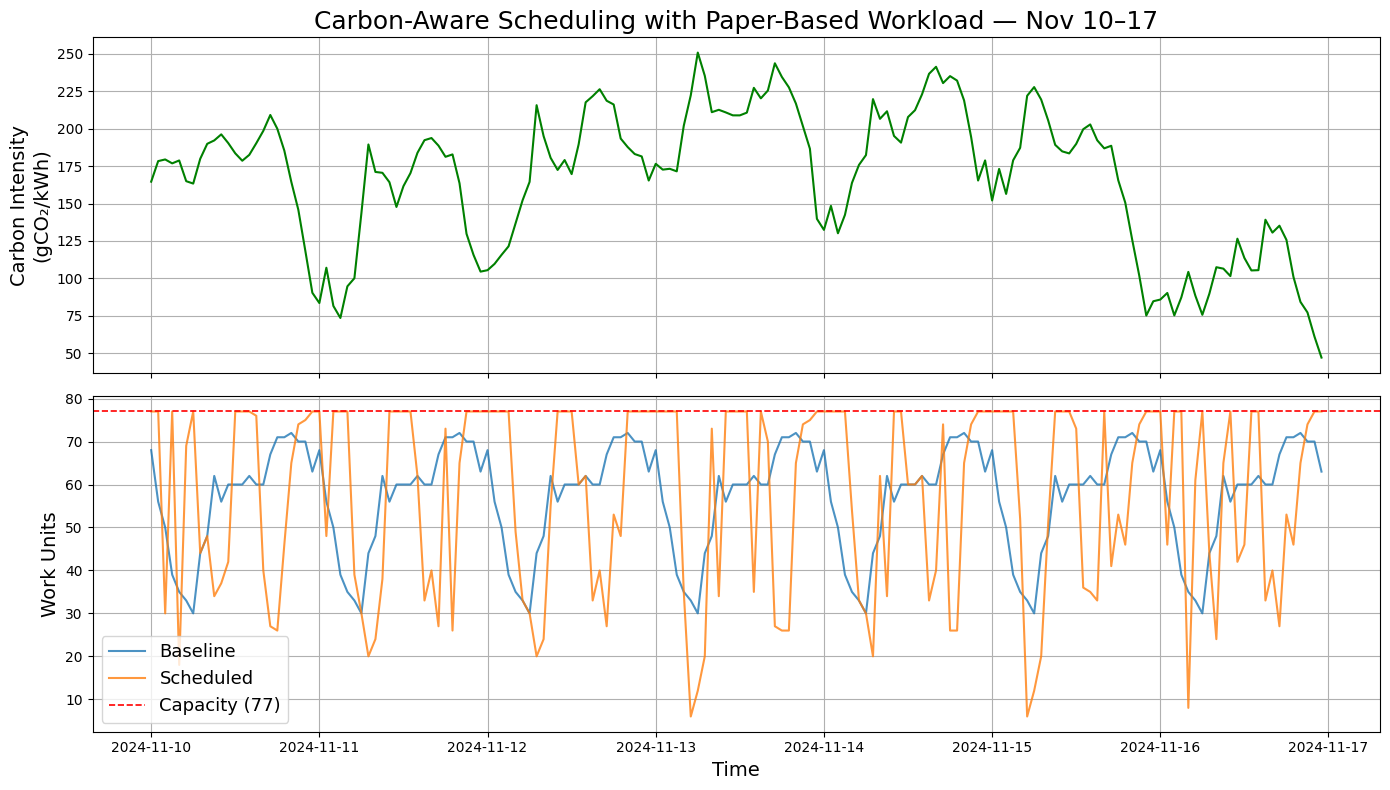

In [25]:
start = "2024-11-10"
end = "2024-11-17"
mask = (pred["time"] >= start) & (pred["time"] < end)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(pred.loc[mask, "time"], ci[mask], color="green", linewidth=1.5)
ax1.set_ylabel("Carbon Intensity\n(gCO₂/kWh)", fontsize=14)
ax1.set_title("Carbon-Aware Scheduling with Paper-Based Workload — Nov 10–17", fontsize=18)
ax1.grid(True)

ax2.plot(pred.loc[mask, "time"], baseline_run[mask], label="Baseline", linewidth=1.5, alpha=0.8)
ax2.plot(pred.loc[mask, "time"], scheduled_run[mask], label="Scheduled", linewidth=1.5, alpha=0.8)
ax2.axhline(capacity, color="red", linestyle="--", linewidth=1.2, label=f"Capacity ({capacity:.0f})")
ax2.set_ylabel("Work Units", fontsize=14)
ax2.set_xlabel("Time", fontsize=14)
ax2.legend(fontsize=13)
ax2.grid(True)

plt.tight_layout()
plt.savefig("fig_scheduler_paper_workload.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()